In [1]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import matplotlib.patches as patches


image 1/1 C:\Users\user\Documents\GitHub\Korean_Food_Detection\hospital plates\1-b.jpg: 384x512 5 foods, 17.0ms
Speed: 3.0ms preprocess, 17.0ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 512)


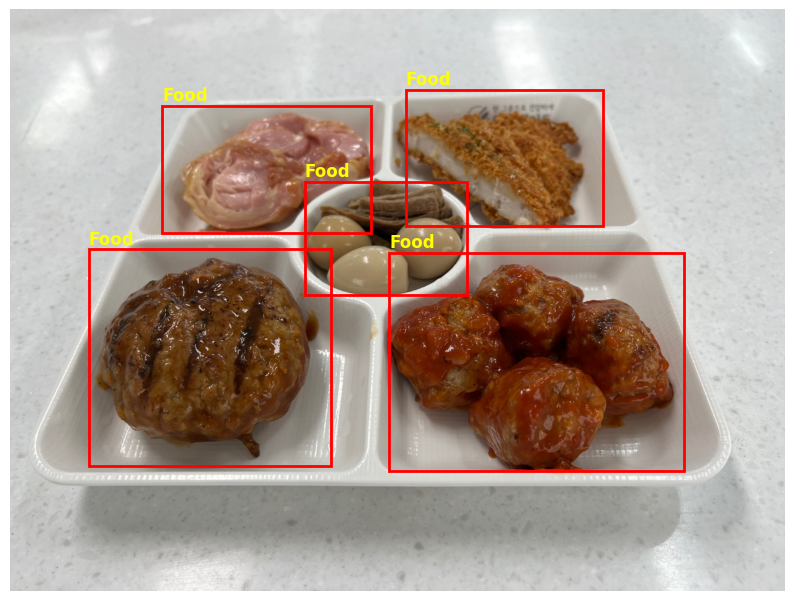

In [5]:


# Function to plot the image with bounding boxes
def plot_image_with_boxes(image_path, results):
    """
    Plots the image with YOLOv8 results, replacing class names with "Food" and removing confidence scores.

    Parameters:
    - image_path (str): Path to the image file.
    - results (Results object): YOLOv8 results after inference.
    """
    # Load the image
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)

    # Loop through detections
    for result in results[0].boxes:
        box = result.xyxy[0].cpu().numpy()  # Convert to CPU and then to NumPy
        
        # Extract box coordinates
        x_min, y_min, x_max, y_max = box
        
        # Add bounding box
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Add label "Food" above the bounding box
        ax.text(x_min, y_min - 10, "Food", color='yellow', fontsize=12, weight='bold')

    plt.axis('off')
    plt.show()

# Load YOLOv8 model
model = YOLO(r"C:\Users\user\Documents\GitHub\Korean_Food_Detection\tools\best_multiple_plates.pt")  # Replace with your model path

# Perform inference
image_path = r"C:\Users\user\Documents\GitHub\Korean_Food_Detection\hospital plates\1-b.jpg"  # Replace with your image path
results = model(image_path)

# Plot results
plot_image_with_boxes(image_path, results)
